DATA TABLE:
    Month  Temperature  Sales
0       1            5      5
1       2            7      4
2       3           10      4
3       4           15      6
4       5           20     10
5       6           25     15
6       7           29     20
7       8           29     21
8       9           20     15
9      10           15     10
10     11           10      5
11     12            5      5



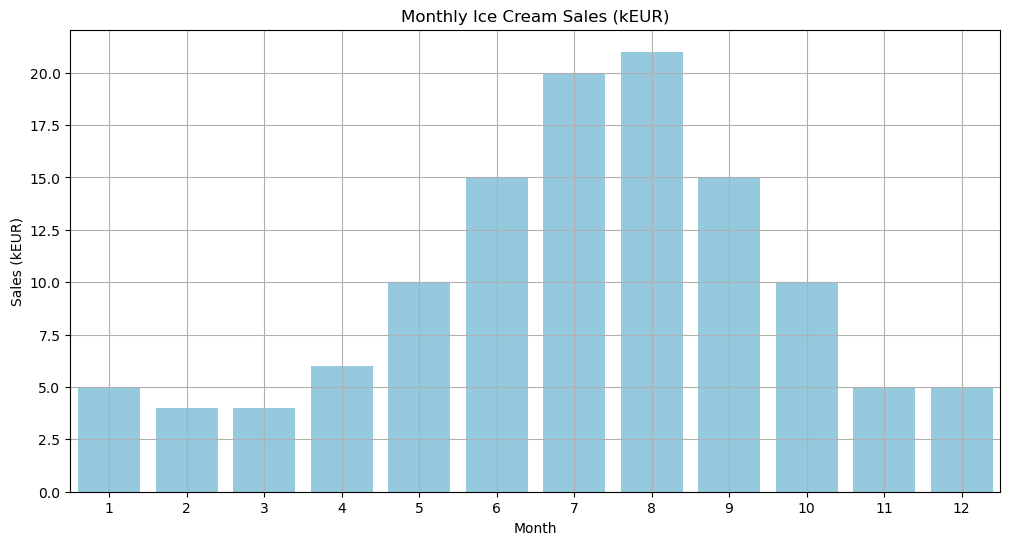

Temperature: 30 °C → Predicted sales: 19.6 kEUR



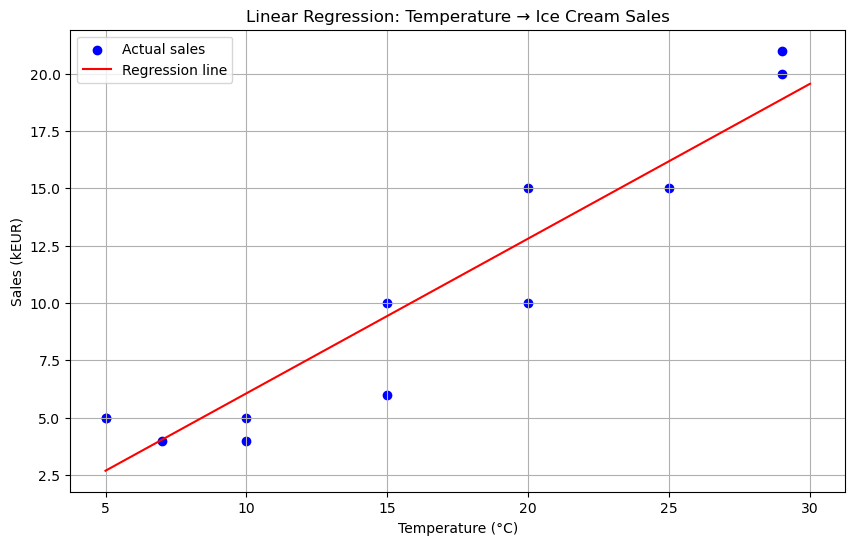

In [8]:
# GOAL OF THIS SCRIPT
# ---------------------------------------------------------
# This script demonstrates:
# 1) A Seaborn bar chart of monthly ice cream sales
# 2) Linear Regression (predict sales from temperature)
# 3) A regression line figure
#
# Uses your ice cream dataset:
# - Temperature (°C)
# - Sales (kEUR)
# - Months 1–12
# ---------------------------------------------------------

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ---------------------------------------------------------
# DATA
# ---------------------------------------------------------

months = list(range(1, 13))
temperature = np.array([5, 7, 10, 15, 20, 25, 29, 29, 20, 15, 10, 5])
sales = np.array([5, 4, 4, 6, 10, 15, 20, 21, 15, 10, 5, 5])

df = pd.DataFrame({
    "Month": months,
    "Temperature": temperature,
    "Sales": sales
})

print("DATA TABLE:")
print(df)
print()

# =========================================================
# 1) SEABORN BAR CHART — MONTHLY SALES
# =========================================================

plt.figure(figsize=(12, 6))
sns.barplot(x="Month", y="Sales", data=df, color="skyblue")

plt.title("Monthly Ice Cream Sales (kEUR)")
plt.xlabel("Month")
plt.ylabel("Sales (kEUR)")
plt.grid(True)
plt.show()

# =========================================================
# 2) LINEAR REGRESSION — Temperature → Sales
# =========================================================

X = temperature.reshape(-1, 1)   # scikit-learn expects 2D input
y = sales

model = LinearRegression()
model.fit(X, y)

# Predict for a new temperature
new_temp = 30
predicted_sales = model.predict([[new_temp]])
print("Temperature:", new_temp, "°C → Predicted sales:", round(predicted_sales[0], 1), "kEUR")

print()

# =========================================================
# 3) REGRESSION LINE PLOT
# =========================================================

# Create smooth temperature range for plotting
temp_range = np.linspace(5, 30, 200).reshape(-1, 1)
predicted_range = model.predict(temp_range)

plt.figure(figsize=(10, 6))

# Actual data points
plt.scatter(temperature, sales, color="blue", label="Actual sales")

# Regression line
plt.plot(temp_range, predicted_range, color="red", label="Regression line")

plt.title("Linear Regression: Temperature → Ice Cream Sales")
plt.xlabel("Temperature (°C)")
plt.ylabel("Sales (kEUR)")
plt.grid(True)
plt.legend()
plt.show()
